In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/zomato_clean_dataset_india.csv')

In [3]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,cuisine_count,area_popularity,cost_numeric,cost_category,restaurant_type
0,Rainfall Restaurant - Flora Charishma,"Biryani, Chinese, South Indian, Kerala, North ...",₹700 for two,4.4,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,7,18,700.0,Medium,Premium
1,Zodiac - All Day Dining - Fortune Airport Road...,"North Indian, Chinese, South Indian, Continent...","₹2,000 for two",3.1,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,7,18,2000.0,High,Luxury
2,Thalassery Kitchen,"North Indian, Kerala, South Indian, Chinese, S...",₹500 for two,3.9,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,6,18,500.0,Low,Casual
3,Ila Restaurant Beirut Cafe,"Chinese, South Indian, Kerala",₹400 for two,4.0,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,3,18,400.0,Low,Casual
4,Paradise Restaurant,"Kerala, Biryani",₹300 for two,NaN,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,2,18,300.0,Low,Casual


In [4]:
df.dtypes

,0
name,object
cuisine,object
price,object
rating,float64
city,object
area,object
restaurant_link,object
status,object
has_online_delivery,object
has_table_booking,object


In [5]:
df.drop_duplicates(subset=["name", "city", "area"], inplace=True)
print("Rows after duplicates:", len(df))

Rows after duplicates: 2745


In [6]:
df["city"].value_counts()

,count
city,
alappuzha,131
kochi,81
kolkata,80
lucknow,72
goa,72
chandigarh,72
shimla,72
pune,72
puducherry,72


In [7]:
df.isnull().sum()

,0
name,0
cuisine,285
price,1
rating,215
city,0
area,0
restaurant_link,0
status,0
has_online_delivery,0
has_table_booking,0


In [8]:
df.describe()

,rating,cuisine_count,area_popularity,cost_numeric
count,2530.000000,2745.000000,2745.000000,2744.000000
mean,4.243241,4.630965,19.730055,1050.796647
std,0.373642,2.469579,6.312933,783.133653
min,2.600000,1.000000,2.000000,40.000000
25%,4.000000,2.000000,18.000000,400.000000
50%,4.300000,5.000000,18.000000,1000.000000
75%,4.500000,7.000000,18.000000,1500.000000
max,4.900000,8.000000,54.000000,6000.000000


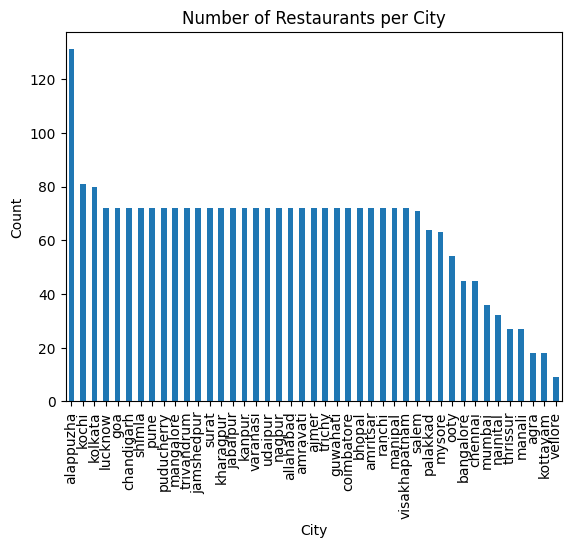

In [9]:
df["city"].value_counts().plot(kind="bar")
plt.title("Number of Restaurants per City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

In [10]:
# Convert rating to numeric (important)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Group by city and calculate average rating
city_rating = df.groupby("city")["rating"].mean().reset_index()

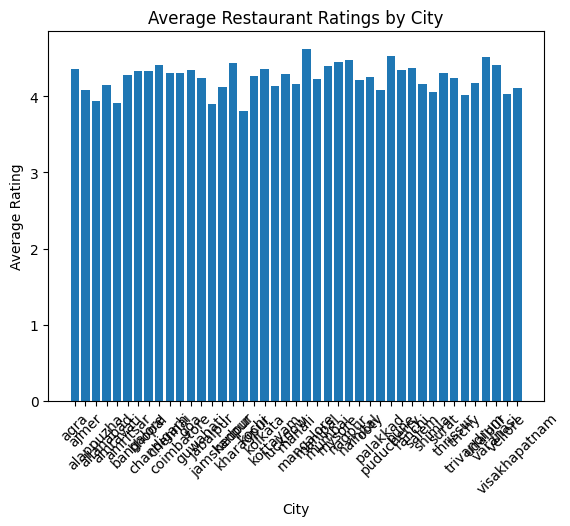

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(city_rating["city"], city_rating["rating"])

plt.xlabel("City")
plt.ylabel("Average Rating")
plt.title("Average Restaurant Ratings by City")

plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='Frequency'>

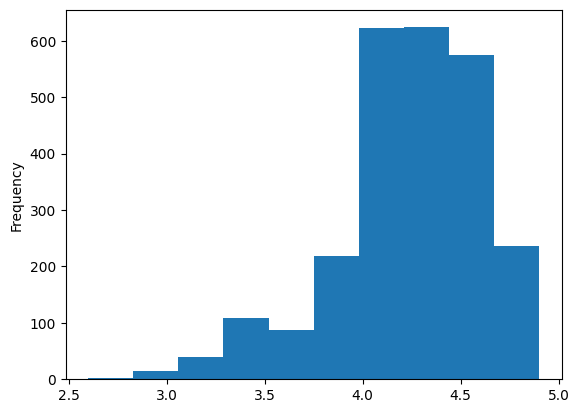

In [12]:
df["rating"].plot(kind="hist", bins=10)

<Axes: ylabel='Frequency'>

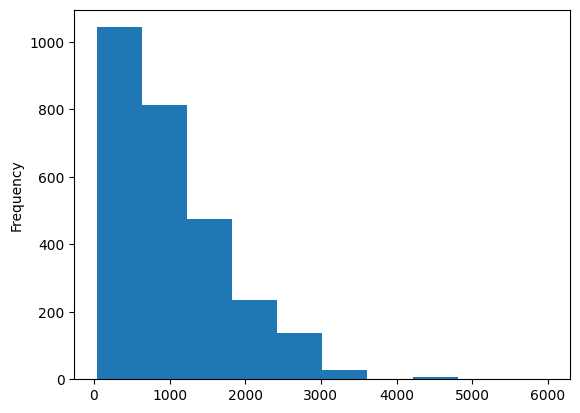

In [13]:
df["cost_numeric"].plot(kind="hist", bins=10)

<Axes: xlabel='area'>

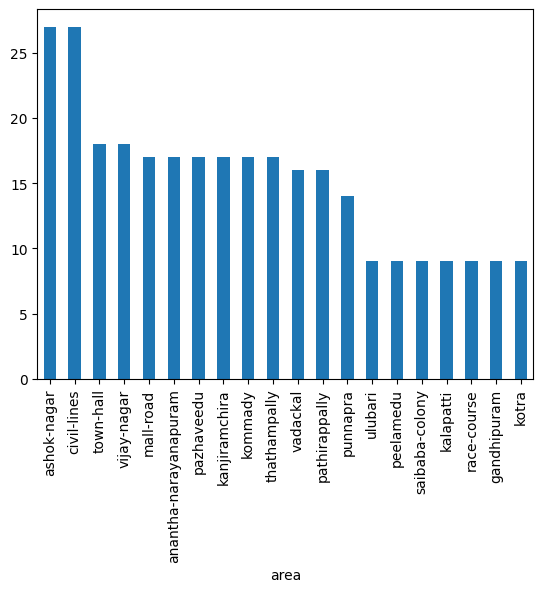

In [14]:
df["area"].value_counts().head(20).plot(kind="bar")

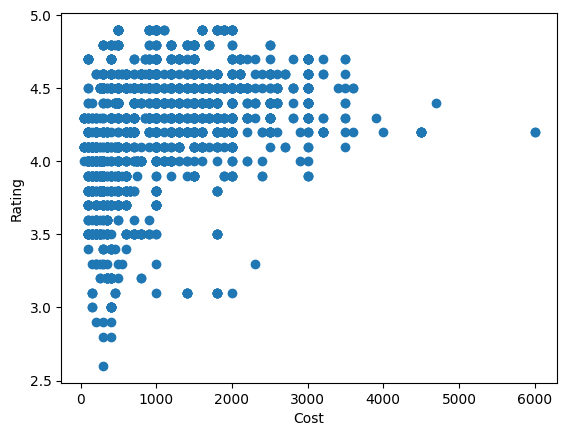

In [15]:
import matplotlib.pyplot as plt

plt.scatter(df["cost_numeric"], df["rating"])
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.show()

In [16]:
df.groupby("has_online_delivery")["rating"].mean()

,rating
has_online_delivery,
No,4.246782
Yes,4.239985


<Axes: >

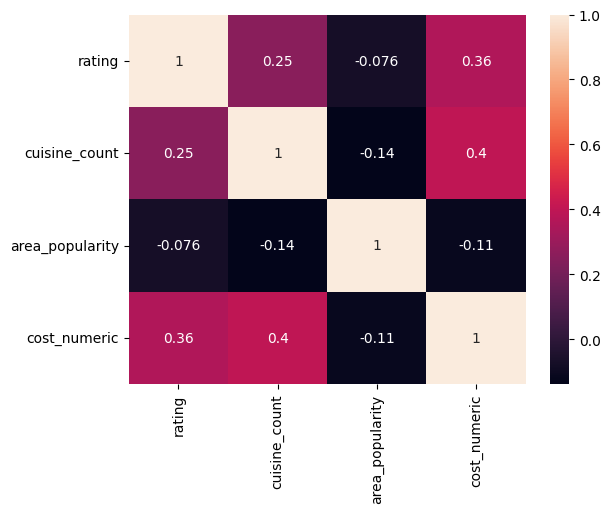

In [17]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [18]:
# fill null values

In [19]:
df["rating"].fillna(df["rating"].mean(), inplace=True)


In [20]:
df["cuisine"].fillna("Unknown", inplace=True)
df["price"].fillna("Not Available", inplace=True)
df["cost_numeric"].fillna("Not Available", inplace=True)



/tmp/ipykernel_6203/895137462.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cuisine"].fillna("Unknown", inplace=True)
/tmp/ipykernel_6203/895137462.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [21]:
df.isnull().sum()

,0
name,0
cuisine,0
price,0
rating,0
city,0
area,0
restaurant_link,0
status,0
has_online_delivery,0
has_table_booking,0


In [22]:
# Cuisine encoding----> Multilabel Binarizer

In [23]:
#df["cuisine"] = df["cuisine"].str.lower().str.strip()

In [24]:
df["cuisine"] = df["cuisine"].str.lower().str.strip()

df["cuisine_list"] = df["cuisine"].apply(
    lambda x: [i.strip() for i in x.split(",")]
)

In [25]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

encoded = mlb.fit_transform(df["cuisine_list"])

In [26]:
cuisine_df = pd.DataFrame(encoded, columns=mlb.classes_)
df = pd.concat([df, cuisine_df], axis=1)

In [27]:
#cuisine_dummies = df["cuisine"].str.get_dummies(sep=",")
#df = pd.concat([df, cuisine_dummies], axis=1)

In [28]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,sushi,tamil,tea,thai,tibetan,turkish,unknown,vietnamese,waffle,wraps
0,Rainfall Restaurant - Flora Charishma,"biryani, chinese, south indian, kerala, north ...",₹700 for two,4.400000,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Zodiac - All Day Dining - Fortune Airport Road...,"north indian, chinese, south indian, continent...","₹2,000 for two",3.100000,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Thalassery Kitchen,"north indian, kerala, south indian, chinese, s...",₹500 for two,3.900000,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ila Restaurant Beirut Cafe,"chinese, south indian, kerala",₹400 for two,4.000000,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Paradise Restaurant,"kerala, biryani",₹300 for two,4.243241,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
cost_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["cost_category_encoded"] = df["cost_category"].map(cost_map)

In [30]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,tamil,tea,thai,tibetan,turkish,unknown,vietnamese,waffle,wraps,cost_category_encoded
0,Rainfall Restaurant - Flora Charishma,"biryani, chinese, south indian, kerala, north ...",₹700 for two,4.400000,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Zodiac - All Day Dining - Fortune Airport Road...,"north indian, chinese, south indian, continent...","₹2,000 for two",3.100000,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,Thalassery Kitchen,"north indian, kerala, south indian, chinese, s...",₹500 for two,3.900000,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ila Restaurant Beirut Cafe,"chinese, south indian, kerala",₹400 for two,4.000000,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Paradise Restaurant,"kerala, biryani",₹300 for two,4.243241,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[["restaurant_type"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["restaurant_type"])
)

df = pd.concat([df, encoded_df], axis=1)

In [32]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,tibetan,turkish,unknown,vietnamese,waffle,wraps,cost_category_encoded,restaurant_type_Luxury,restaurant_type_Premium,restaurant_type_nan
0,Rainfall Restaurant - Flora Charishma,"biryani, chinese, south indian, kerala, north ...",₹700 for two,4.400000,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,Zodiac - All Day Dining - Fortune Airport Road...,"north indian, chinese, south indian, continent...","₹2,000 for two",3.100000,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0
2,Thalassery Kitchen,"north indian, kerala, south indian, chinese, s...",₹500 for two,3.900000,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ila Restaurant Beirut Cafe,"chinese, south indian, kerala",₹400 for two,4.000000,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Paradise Restaurant,"kerala, biryani",₹300 for two,4.243241,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
tier1 = ["bangalore", "mumbai", "delhi", "kolkata" "chennai", "hyderabad"]

tier2 = ["kochi", "jaipur", "lucknow", "chandigarh", "pune", "ahmedabad", "trivandrum","mysore"]

# others → Tier 3

In [34]:
def get_city_tier(city):
    if city in tier1:
        return "Tier 1"
    elif city in tier2:
        return "Tier 2"
    else:
        return "Tier 3"

In [35]:
df["city"] = df["city"].str.lower().str.strip()

df["city_tier"] = df["city"].apply(get_city_tier)

In [36]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,turkish,unknown,vietnamese,waffle,wraps,cost_category_encoded,restaurant_type_Luxury,restaurant_type_Premium,restaurant_type_nan,city_tier
0,Rainfall Restaurant - Flora Charishma,"biryani, chinese, south indian, kerala, north ...",₹700 for two,4.400000,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,Tier 2
1,Zodiac - All Day Dining - Fortune Airport Road...,"north indian, chinese, south indian, continent...","₹2,000 for two",3.100000,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,...,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,Tier 2
2,Thalassery Kitchen,"north indian, kerala, south indian, chinese, s...",₹500 for two,3.900000,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tier 2
3,Ila Restaurant Beirut Cafe,"chinese, south indian, kerala",₹400 for two,4.000000,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tier 2
4,Paradise Restaurant,"kerala, biryani",₹300 for two,4.243241,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tier 2


In [37]:
# Encoding city tier -->

In [38]:
tier_map = {
    "Tier 3": 1,
    "Tier 2": 2,
    "Tier 1": 3
}

df["city_tier_encoded"] = df["city_tier"].map(tier_map)

In [39]:
df.head()

,name,cuisine,price,rating,city,area,restaurant_link,status,has_online_delivery,has_table_booking,...,unknown,vietnamese,waffle,wraps,cost_category_encoded,restaurant_type_Luxury,restaurant_type_Premium,restaurant_type_nan,city_tier,city_tier_encoded
0,Rainfall Restaurant - Flora Charishma,"biryani, chinese, south indian, kerala, north ...",₹700 for two,4.400000,kochi,aluva,https://www.zomato.com/kochi/rainfall-restaura...,Open,No,Yes,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,Tier 2,2
1,Zodiac - All Day Dining - Fortune Airport Road...,"north indian, chinese, south indian, continent...","₹2,000 for two",3.100000,kochi,aluva,https://www.zomato.com/kochi/zodiac-all-day-di...,Open,Yes,No,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,Tier 2,2
2,Thalassery Kitchen,"north indian, kerala, south indian, chinese, s...",₹500 for two,3.900000,kochi,aluva,https://www.zomato.com/kochi/thalassery-kitche...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tier 2,2
3,Ila Restaurant Beirut Cafe,"chinese, south indian, kerala",₹400 for two,4.000000,kochi,aluva,https://www.zomato.com/kochi/ila-restaurant-be...,Open,No,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tier 2,2
4,Paradise Restaurant,"kerala, biryani",₹300 for two,4.243241,kochi,aluva,https://www.zomato.com/kochi/paradise-restaura...,Closed,Yes,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tier 2,2


In [40]:
# final data set for training

In [41]:
df_eda = df.drop(columns=[

    "name",
     "cuisine_list",
    "restaurant_link",
    "area",
    "restaurant_type",
    "price",
    "cost_category",
    "city_tier",
    "cuisine",
    "status",
    "has_table_booking",
    "has_online_delivery",

])

In [42]:
df_eda.head()

,rating,city,cuisine_count,area_popularity,cost_numeric,african,alcoholic beverages,american,andhra,arabian,...,turkish,unknown,vietnamese,waffle,wraps,cost_category_encoded,restaurant_type_Luxury,restaurant_type_Premium,restaurant_type_nan,city_tier_encoded
0,4.400000,kochi,7.0,18.0,700.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
1,3.100000,kochi,7.0,18.0,2000.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,2
2,3.900000,kochi,6.0,18.0,500.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,4.000000,kochi,3.0,18.0,400.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,4.243241,kochi,2.0,18.0,300.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
